# Student Performance Analysis

## Data Analytics Internship Project

### Objective
Analyze student performance data to identify factors affecting academic achievement, detect at-risk students, and provide actionable recommendations for school improvement.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [3]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive (1).zip


In [5]:
import zipfile

with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall()

print("ZIP extracted successfully")

ZIP extracted successfully


In [6]:
import os

os.listdir()

['.config',
 'archive.zip',
 'archive (1).zip',
 'StudentsPerformance.csv',
 'sample_data']

In [7]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.shape

(1000, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['total_score'] = (
    df['math score']
    + df['reading score']
    + df['writing score']
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [14]:
df['average_score'] = df['total_score'] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Average Math Score:", round(df['math score'].mean(),2))

Rows: 1000
Columns: 10
Missing Values: 0
Duplicate Rows: 0
Average Math Score: 66.09


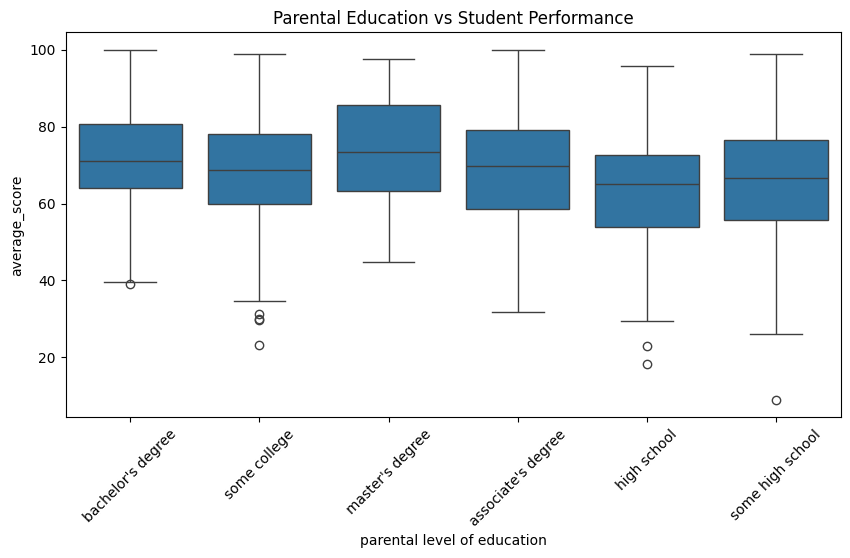

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    x='parental level of education',
    y='average_score',
    data=df
)

plt.xticks(rotation=45)
plt.title("Parental Education vs Student Performance")

plt.show()

### Insight

Students whose parents have master's or bachelor's degrees tend to have slightly higher average scores.

Students whose parents have high school education show a wider variation in performance.

A few outliers with very low scores are visible across several education groups.

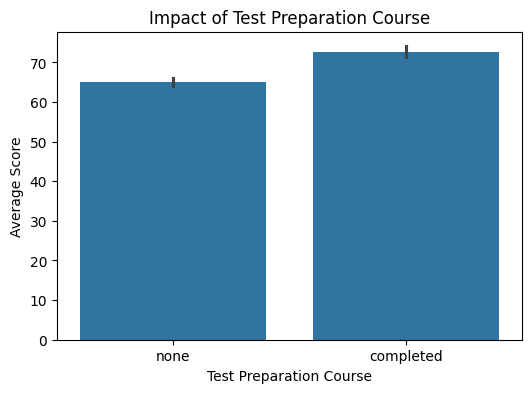

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='test preparation course',
    y='average_score',
    data=df
)

plt.title("Impact of Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")

plt.show()

### Insight

Students who completed the test preparation course achieved higher average scores than those who did not complete it.

The difference in performance suggests that test preparation positively influences academic outcomes.

Schools should encourage participation in preparation programs to improve overall student achievement.

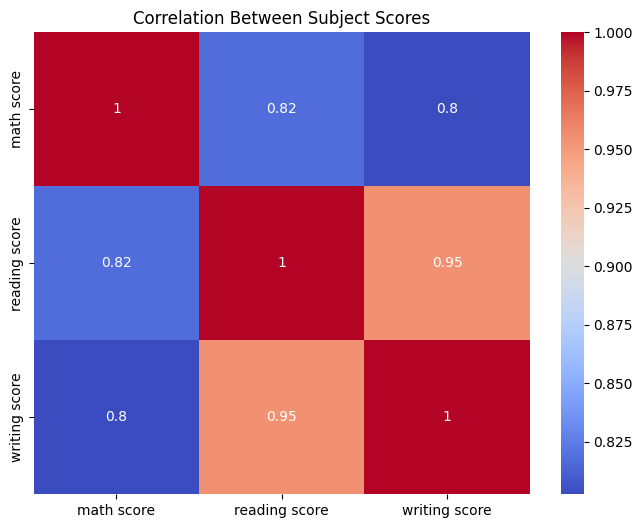

In [19]:
corr = df[
    ['math score',
     'reading score',
     'writing score']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Subject Scores")

plt.show()

### Insight

Reading and writing scores show a very strong positive correlation.

Students who perform well in reading generally perform well in writing.

Math scores are also positively correlated with reading and writing, though slightly less strongly.

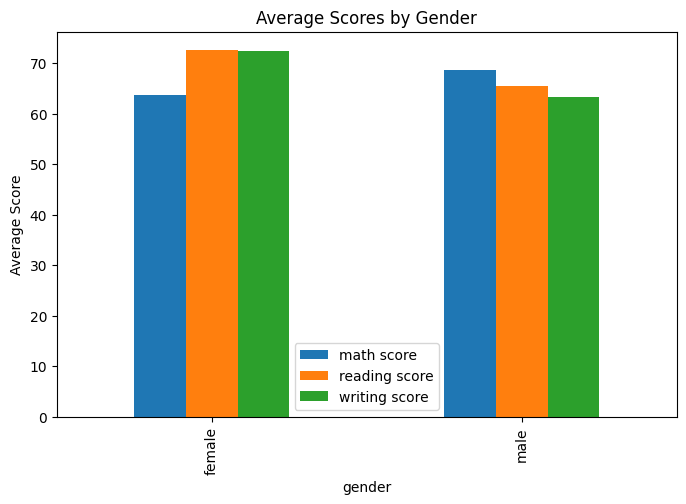

In [20]:
gender_scores = df.groupby('gender')[
    ['math score',
     'reading score',
     'writing score']
].mean()

gender_scores.plot(kind='bar', figsize=(8,5))

plt.title("Average Scores by Gender")
plt.ylabel("Average Score")

plt.show()

### Insight

Male students tend to perform better in mathematics.

Female students generally score higher in reading and writing.

Performance differences suggest subject-specific strengths across genders.

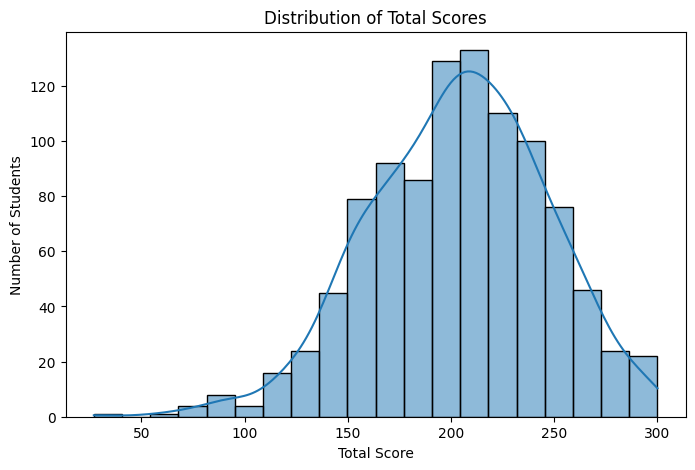

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['total_score'],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

### Insight

Most students score within the middle range of total marks.

The distribution appears approximately normal, indicating that the majority of students perform around the average level.

Only a small number of students achieve extremely low or extremely high scores.

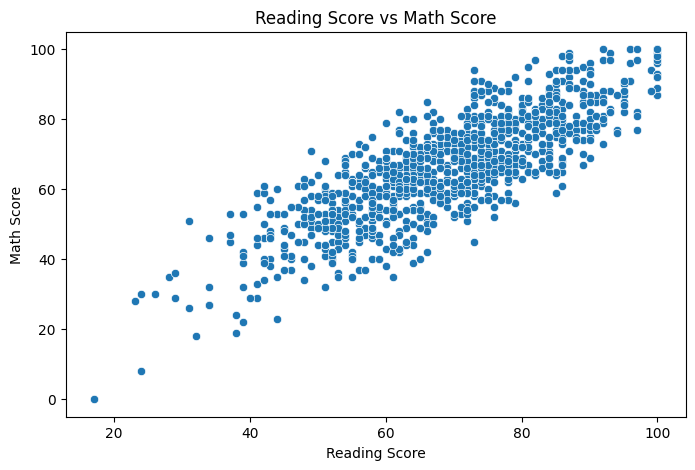

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='reading score',
    y='math score',
    data=df
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.show()

### Insight

Students with higher reading scores generally tend to achieve higher math scores.

The positive trend suggests a relationship between overall academic ability and performance across subjects.

A few outliers are present but do not significantly affect the overall trend.

In [23]:
df['at_risk'] = (
    (df['math score'] < 50) |
    (df['reading score'] < 50) |
    (df['writing score'] < 50)
)

In [24]:
df['at_risk'].value_counts()

,count
at_risk,
False,812
True,188


In [25]:
(df['at_risk'].value_counts(normalize=True) * 100).round(2)

,proportion
at_risk,
False,81.2
True,18.8


In [26]:
pd.crosstab(
    df['gender'],
    df['at_risk'],
    normalize='index'
) * 100

at_risk,False,True
gender,,
female,82.818533,17.181467
male,79.460581,20.539419


In [27]:
pd.crosstab(
    df['test preparation course'],
    df['at_risk'],
    normalize='index'
) * 100

at_risk,False,True
test preparation course,,
completed,89.944134,10.055866
none,76.323988,23.676012


# At-Risk Student Analysis

Students scoring below 50 in at least one subject were classified as at-risk.

The analysis shows that students who did not complete the test preparation course have a higher proportion of at-risk cases.

Targeted intervention programs should focus on these students to improve academic outcomes.

# Principal's Report

## Executive Summary

Student performance data was analyzed to identify factors influencing academic achievement. Test preparation and parental education level were found to significantly affect student outcomes. A group of academically at-risk students was identified for targeted support and intervention.

## Key Findings

1. Students who completed test preparation scored higher on average.
2. Higher parental education levels are associated with better student performance.
3. Reading and writing scores show a strong positive correlation.
4. Male students generally perform better in mathematics.
5. Female students generally perform better in reading and writing.

## Recommendations

### 1. Expand Test Preparation Programs
Provide structured preparation courses for all students, especially those with lower academic performance.

### 2. Early Identification of At-Risk Students
Monitor students scoring below 50 and provide mentoring, tutoring, and additional academic support.

### 3. Increase Parent Engagement
Conduct workshops and regular progress meetings to encourage parental involvement in student learning.